**IMPORTING ALL NECESSARY LIBRARIES**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns 

In [2]:
df = pd.read_csv("../Data/Raw Data/2019-Nov.csv")
df.head(1)

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session
0,2019-11-01 00:00:00 UTC,view,1003461,2053013555631882655,electronics.smartphone,xiaomi,489.07,520088904,4d3b30da-a5e4-49df-b1a8-ba5943f1dd33


**Dataset Overview**

>This dataset contains user activity data from an e-commerce platform captured on 1st Nov, where each row represents a single action performed by a user during their browsing session.

>This is an event-level data, meaning a single user can appear multiple times based on their actions over time. Because of this, the dataset is well-suited for analyzing user behavior and building a churn prediction model based on how users interact with the platform.

**Features Overview**

>This dataset includes features that capture user activity and behavior on the platform:

>- **event_time** → Timestamp of user action 

>- **event_type** → Type of action (view, cart, purchase)

>- **product_id** → Product identifier

>- **category_code / category_id** → Product category

>- **brand** → Product Brand 

>- **price** → Product Price

>- **user_id** → Unique user identity

>- **user_session** → Session identity

In [3]:
#Checking Shape & type of data
print(f"Rows :{df.shape[0]}")
print(f"Features :{df.shape[1]}")
print(f"Dtypes:{df.dtypes}")

Rows :1048575
Features :9
Dtypes:event_time           str
event_type           str
product_id         int64
category_id        int64
category_code        str
brand                str
price            float64
user_id            int64
user_session         str
dtype: object


**SHAPE,SIZE & TYPE OF DATA**

>- Dataset has above 1 million Rows and 9 features/columns.
We break  event_time immediately so all time-series data will become more clean & simple to work on

In [4]:
#Coverting event_time to Time Series
df['event_time'] = pd.to_datetime(df['event_time'])
#Extracting Hour of the Event
df['event_hour'] = df['event_time'].dt.hour
#Extracting Minute of Event
df['event_min'] = df['event_time'].dt.minute


#Category Split
#category_code is an aggregate of category & subcategory, splitting them
df['category'] = df['category_code'].str.split(".").str[0]
df['sub_category'] = df['category_code'].str.split('.').str[1]

#Data Report after splits
print(f"Rows:{len(df)}",f"\nColumns:{df.shape[1]}")

Rows:1048575 
Columns:13


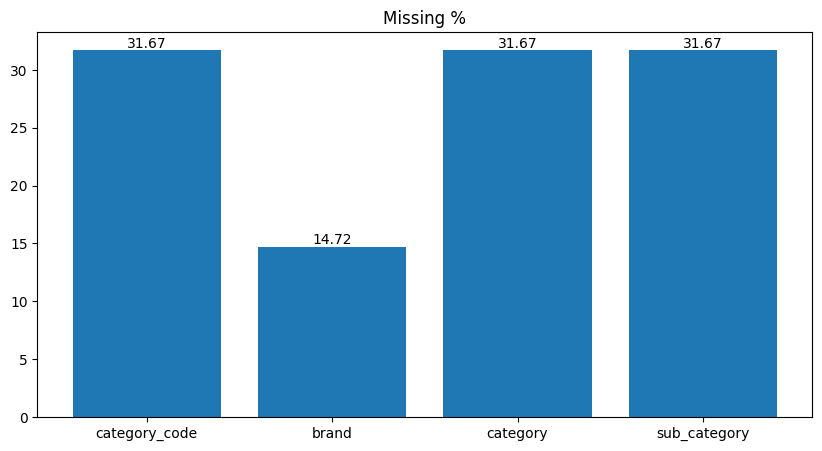

Data has 518 Duplicate values


In [5]:
#Auditing null values
null_df = df.isna().sum()
null_df = null_df[null_df > 0]
null_df = null_df.reset_index()
null_df.columns = ['feature', 'null']
null_df['nullpct'] = round(null_df['null']/len(df) *100,2)
null_df

#Visualization
plt.figure(figsize=[10,5])
plt.title("Missing %")
plt.style.use('ggplot')
bars = plt.bar(null_df['feature'],null_df['nullpct'])
plt.bar_label(bars)
plt.show()

#Duplicates
print(f"Data has {df.duplicated().sum()} Duplicate values")

**DATA QUALITY**

>- Dataset has no duplicates

>- All Category columns & brand column has null values

>- Category column has 31.6% null values & brand has 14.7% missing values which could be due to
uncategorized & non-branded listings 

>- We'll not drop this nulls as these could be meaningful values

In [6]:
#Checking Conversion Rate
conversion_df = df['event_type'].value_counts()
print(f"Cart rate : {round(conversion_df['cart']/conversion_df['view']*100,2)}")
print(f"Purchase rate : {round(conversion_df['purchase']/conversion_df['view']*100,2)}")
print(f"Cart Purchase rate : {round(conversion_df['purchase']/conversion_df['cart'],2)*100}")

Cart rate : 1.52
Purchase rate : 1.81
Cart Purchase rate : 119.0


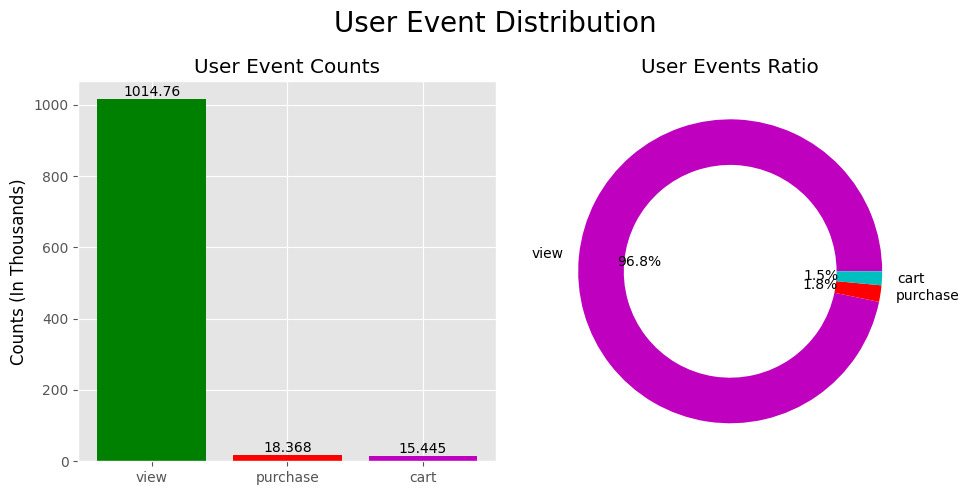

In [7]:
#Visualizing Conversion Rate
dummy = conversion_df.reset_index()
dummy.columns = ['event', 'value']

plt.figure(figsize=(10,5))
plt.suptitle("User Event Distribution",color="black",size=20)
plt.subplot(1,2,1)
plt.title("User Event Counts",color="black")
plt.ylabel("Counts (In Thousands)",c="black")
bars = plt.bar(dummy['event'], dummy['value']/1000,color=["g","r","m"])
plt.bar_label(bars,color="black")
plt.subplot(1,2,2)
plt.title("User Events Ratio",color="black")
plt.pie(dummy['value'],labels=dummy['event'],autopct="%1.1f%%",colors=["m","r","c"],
        textprops={"color":"black"},wedgeprops={'width':0.3})
plt.tight_layout()
plt.show()

**USER EVENT INSIGHTS**
>- Cart & Purchase Rates are 1.5% & 1.8%

>- The cart-to-purchase conversion rate exceeds 100%, indicating that some users may directly purchase without adding items to the cart.

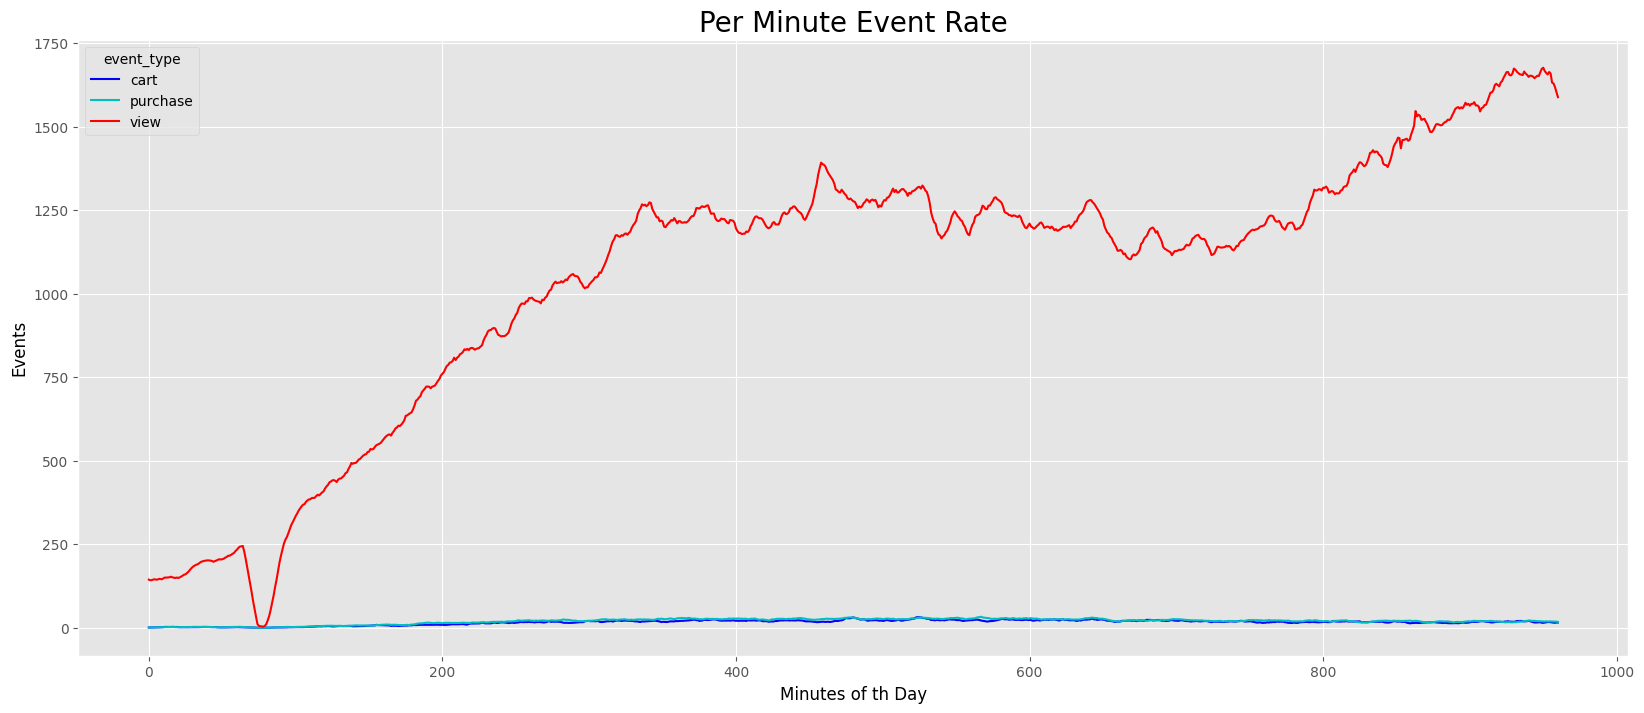

In [8]:
#Minute & Hourly Distribution
df['minute_of_day'] = df['event_hour'] * 60 + df['event_min']
per_minute = df.groupby(['minute_of_day', 'event_type']).size().unstack(fill_value=0)
per_minute_smooth = per_minute.rolling(window=10,center=True,min_periods=1).mean().round(2)

per_hour = df.groupby(["event_hour","event_type"]).size().unstack(fill_value=0)

#Visualization
per_minute_smooth.plot(figsize=(20,8),color=["b","c","r"])
plt.title("Per Minute Event Rate",size=20,color="black")
plt.xlabel("Minutes of th Day",color="black")
plt.ylabel("Events",color='black')
plt.show()

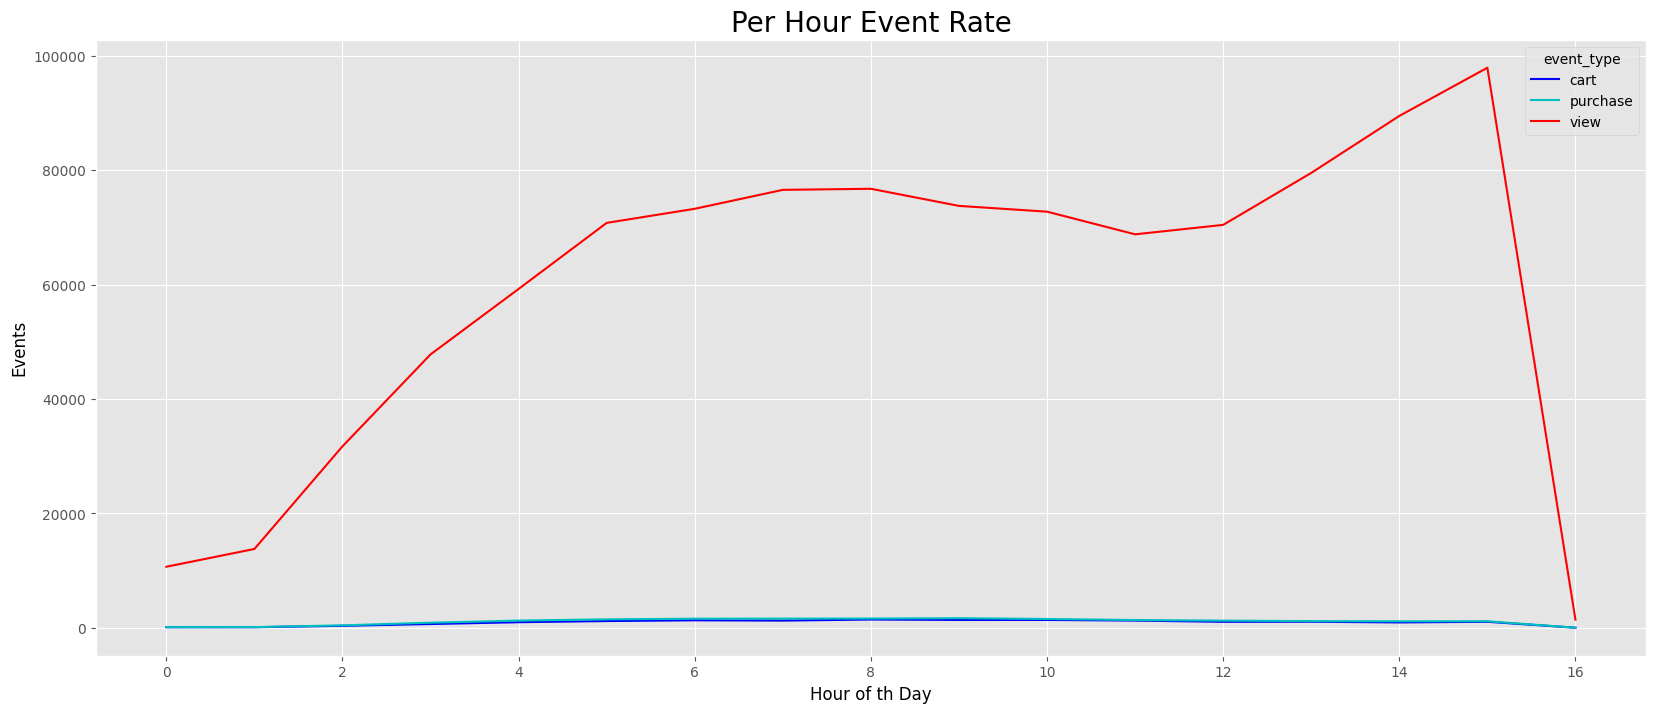

event_hour
15    100115
14     91563
13     81756
8      79818
7      79426
9      76812
6      76155
10     75667
5      73450
12     72744
11     71407
4      61480
3      49348
2      32498
1      14000
0      10887
16      1449
Name: count, dtype: int64


In [9]:
per_hour.plot(figsize=(20,8),color=["b","c","r"])
plt.title("Per Hour Event Rate",size=20,color="black")
plt.xlabel("Hour of th Day",color="black")
plt.ylabel("Events",color='black')
plt.show()
print(df['event_hour'].value_counts())

**TIME INSIGHTS**

>- Views are way more than cart and purchase,which is normal.
>- Traffic starts picking up from hour 4 and peaks around hour 15
>- Traffic goes a sudden long dip after 15th Hour & touches lowest.
>- The data only goes till around 4 PM , so the day is not complete
>- Cart and purchase lines are almost flat compared to views throughout the day
>- Per minute chart shows views growing through the day with some dips in between

C:\Users\Priyanshu sharma\AppData\Local\Temp\ipykernel_9752\882793459.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cats.values/1000,y=cats.index,palette='viridis')


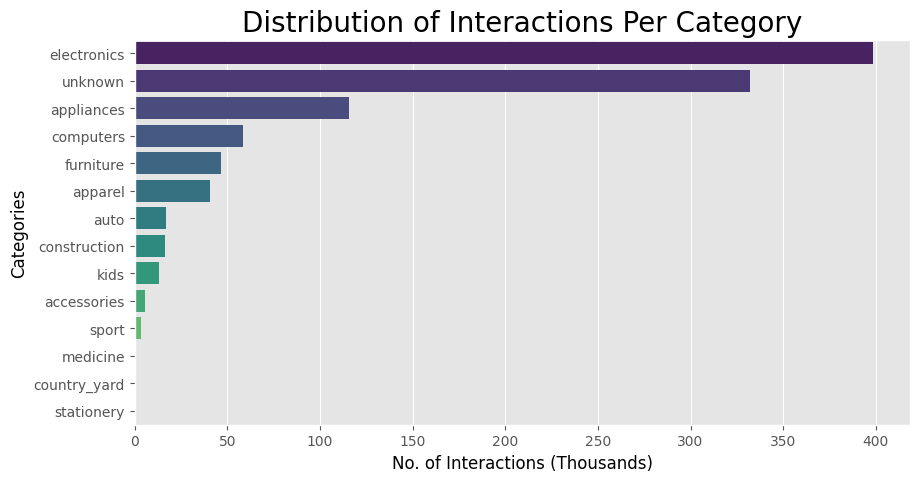

electronics : 37.99%
unknown : 31.67%
appliances : 11.05%
computers : 5.6%
furniture : 4.45%
apparel : 3.88%
auto : 1.64%
construction : 1.54%
kids : 1.24%
accessories : 0.51%
sport : 0.35%
medicine : 0.03%
country_yard : 0.03%
stationery : 0.02%


In [10]:
#Category Analysis
cats = df['category'].fillna('unknown').value_counts()
#Visualization
plt.figure(figsize=(10,5))
sns.barplot(x=cats.values/1000,y=cats.index,palette='viridis')
plt.title('Distribution of Interactions Per Category',size=20,color='black')
plt.xlabel('No. of Interactions (Thousands)',color='black')
plt.ylabel('Categories',color='black')
plt.show()
catpct = df['category'].fillna('unknown').value_counts(normalize=True)*100
catpct = catpct.round(2)
for i,j in catpct.items():
    print(f"{i} : {j}%")

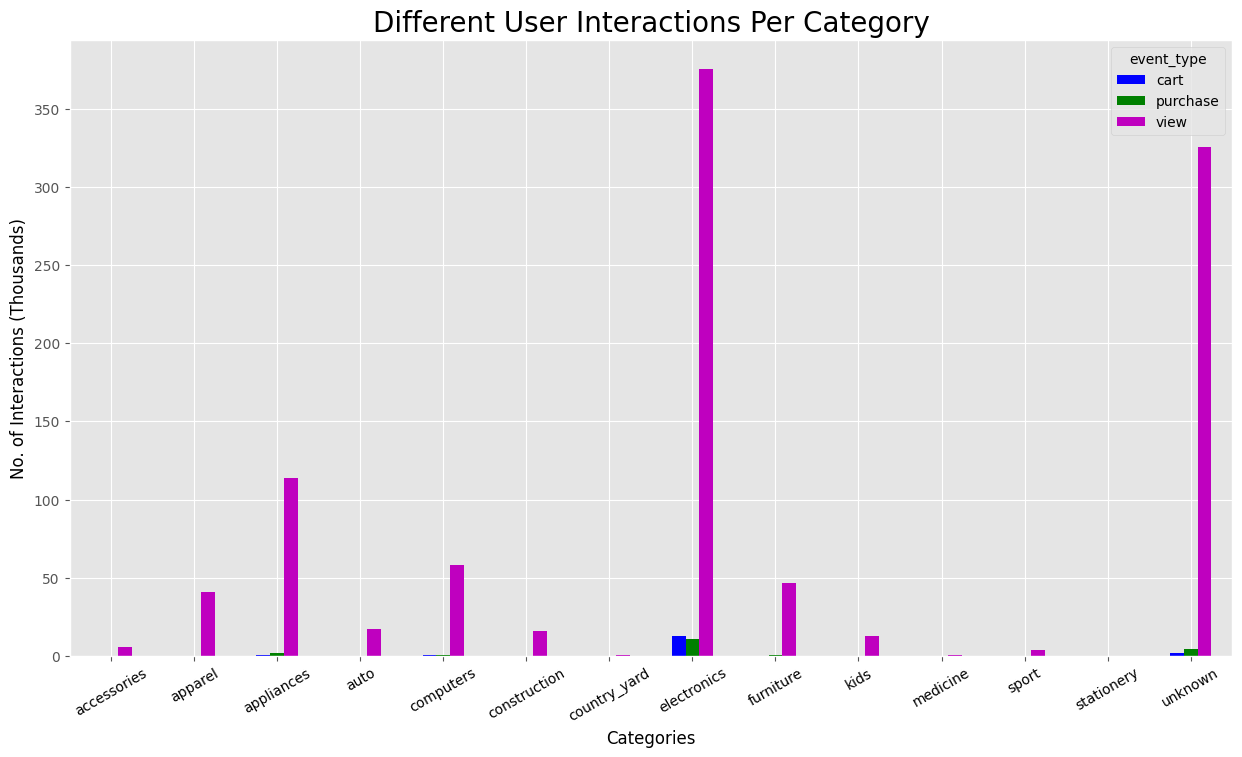

In [11]:
#Category analysis for different events
cats_events= df.fillna('unknown').groupby(['category','event_type']).size().unstack(fill_value=0)
cats_events = cats_events/1000

cats_events.plot(kind='bar',figsize=(15,8),color=['b','g','m'])
plt.title('Different User Interactions Per Category',size=20,color='black')
plt.xlabel('Categories',color='black')
plt.ylabel('No. of Interactions (Thousands)',color='black')
plt.xticks(rotation=30,color='black')
plt.show()

**CATEGORY INSIGHTS**
>- Electronics category dominates with almost 38% share in total user interactions
>- The unknown categories/unlisted category/nulls has the 2nd highest user interactions(31.6%)
>- Top 2 categories have more than 69% of the total user interactions
>- accessories,sport,medicine,country_yard,stationery combined contribute less than 1% of total interactions

C:\Users\Priyanshu sharma\AppData\Local\Temp\ipykernel_9752\1234787789.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_purchase.values,y=top_purchase.index,palette='viridis')


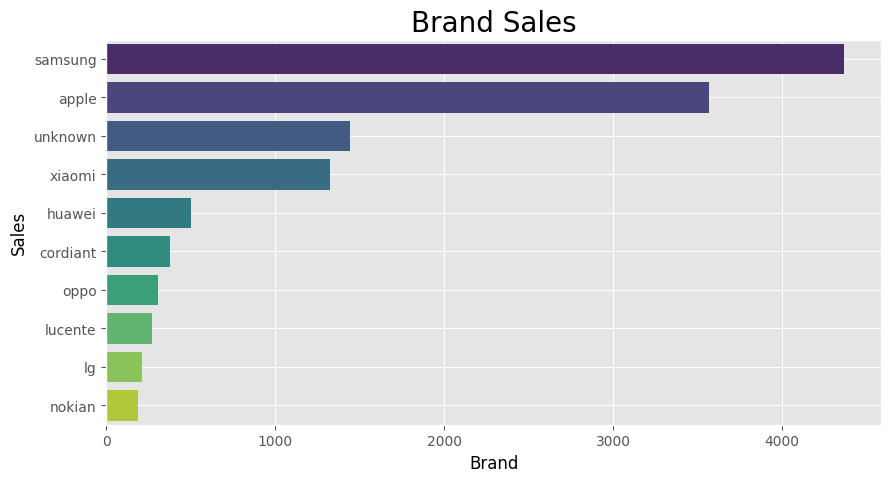

samsung : 23.79%
apple : 19.43%
unknown : 7.85%
xiaomi : 7.22%
huawei : 2.73%
cordiant : 2.06%
oppo : 1.67%
lucente : 1.46%
lg : 1.16%
nokian : 1.03%
Total brands = 2669


In [12]:
#Brand analysis
purchase_df = df[df['event_type']=='purchase']
purchase = purchase_df['brand'].fillna('unknown').value_counts().sort_values(ascending=False)
top_purchase = purchase.head(10)
top_purchase_pct = purchase_df['brand'].fillna('unknown').value_counts(normalize=True).sort_values(ascending=False).head(10)*100
top_purchase_pct = top_purchase_pct.round(2)


#Visualization
plt.figure(figsize=(10,5))
sns.barplot(x=top_purchase.values,y=top_purchase.index,palette='viridis')
plt.title('Brand Sales',size=20,color='black')
plt.xlabel('Brand',color='black')
plt.ylabel('Sales',color='black')
plt.grid(True)
plt.show()

for i,j in top_purchase_pct.items():
    print(f"{i} : {j}%")
print(f'Total brands = {len(df['brand'].unique())}')


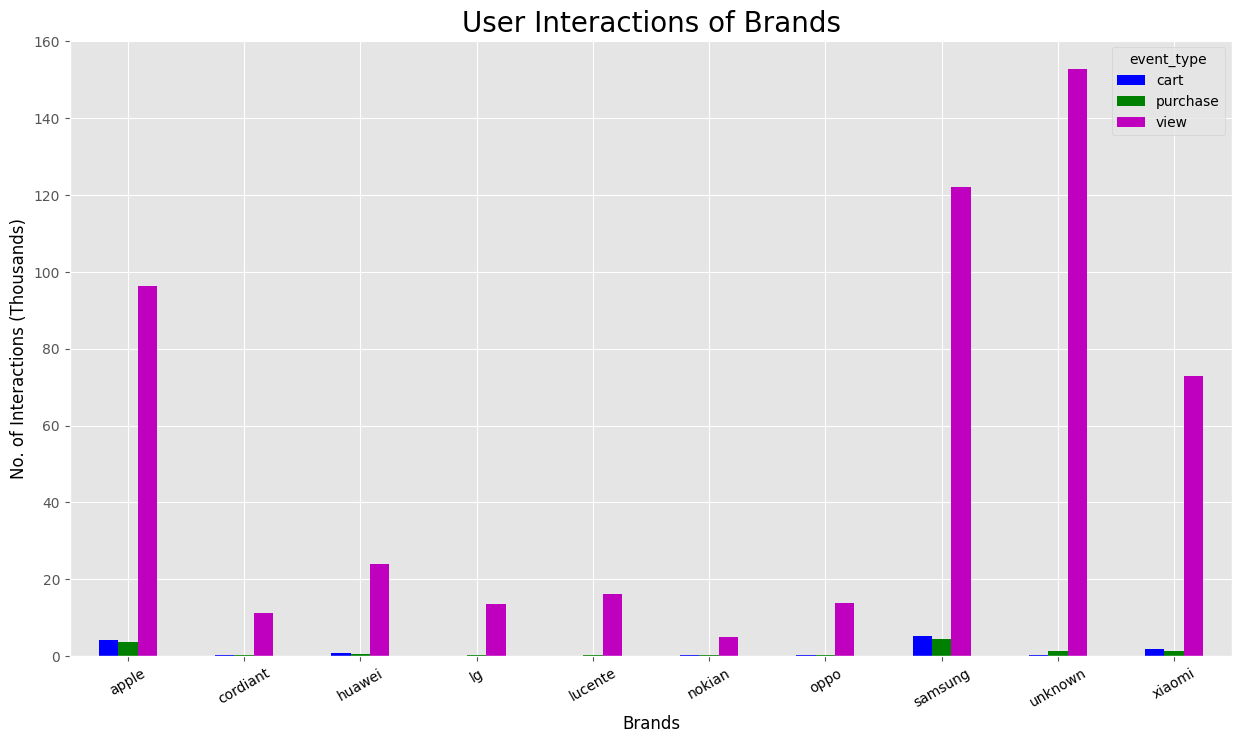

In [13]:
#Brand Event Distribution analysis
brand_events = df.fillna('unknown').groupby(['brand','event_type']).size().sort_values(ascending=False).unstack(fill_value=0)
df2 = df.fillna('unknown')
dummy = df2.loc[df2['brand'].isin(top_purchase.index),['brand','event_type']]
dummy2 = dummy.groupby(['brand','event_type']).size().unstack(fill_value=0)
dummy2 = dummy2/1000

dummy2.plot(kind='bar',figsize=(15,8),color=['b','g','m'])
plt.title('User Interactions of Brands',size=20,color='black')
plt.xlabel('Brands',color='black')
plt.ylabel('No. of Interactions (Thousands)',color='black')
plt.xticks(rotation=30,color='black')
plt.show()

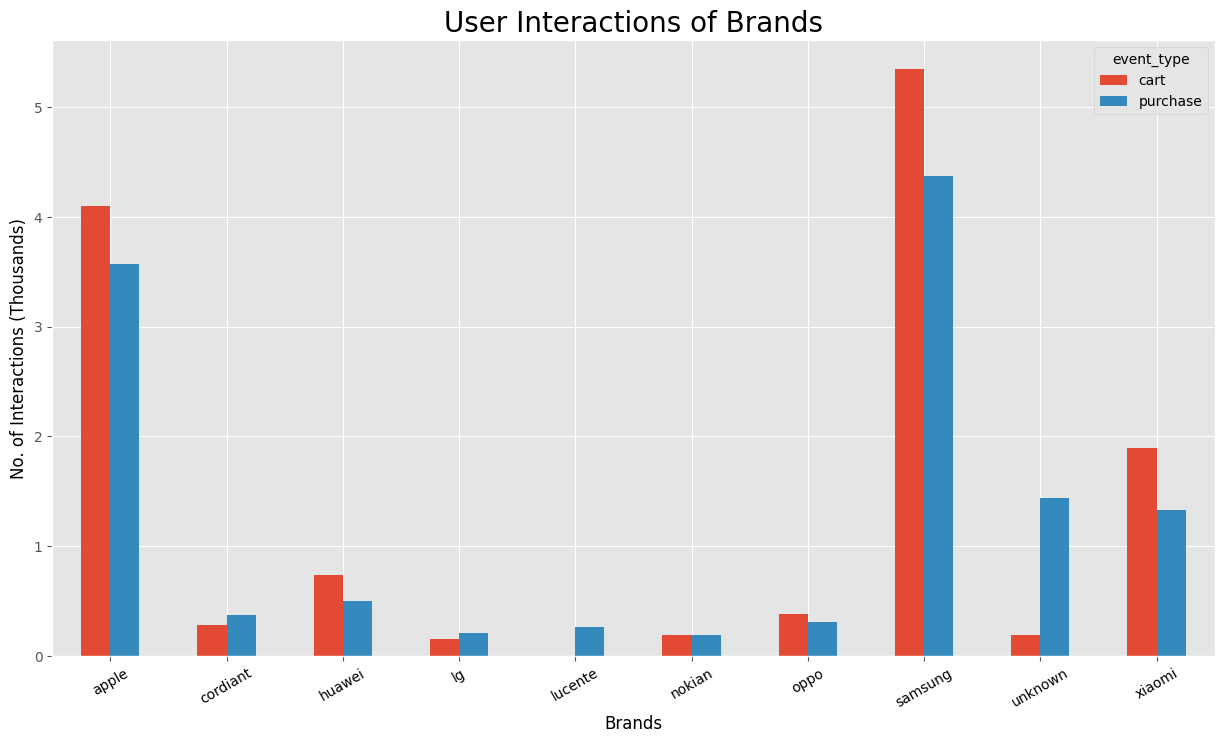

In [14]:
#Cart & Purchase analysis 
dummy2[['cart','purchase']].plot(kind='bar',figsize=(15,8))
plt.title('User Interactions of Brands',size=20,color='black')
plt.xlabel('Brands',color='black')
plt.ylabel('No. of Interactions (Thousands)',color='black')
plt.xticks(rotation=30,color='black')
plt.show()

**BRAND INSIGHTS**
>- samsung & apple dominate in purchases, combined contribute 42%
>- samsung & apple have the highest purchases & cart additions
>- unknown listings/nulls have the highest view interactions
>- We have 2669 brands in total for all categories

C:\Users\Priyanshu sharma\AppData\Local\Temp\ipykernel_9752\2335876287.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(df['price'],palette='viridis')


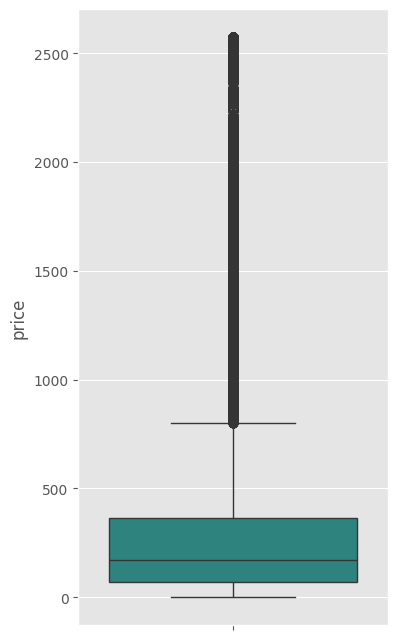

In [15]:
#Price Distribution Analysis
df2 = df.fillna('unknown')

#Checking Outliers
plt.figure(figsize=(4,8))
sns.boxplot(df['price'],palette='viridis')
plt.show()


C:\Users\Priyanshu sharma\AppData\Local\Temp\ipykernel_9752\3357672304.py:3: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(df2['price'],bins=100,kde=True,palette='viridis')


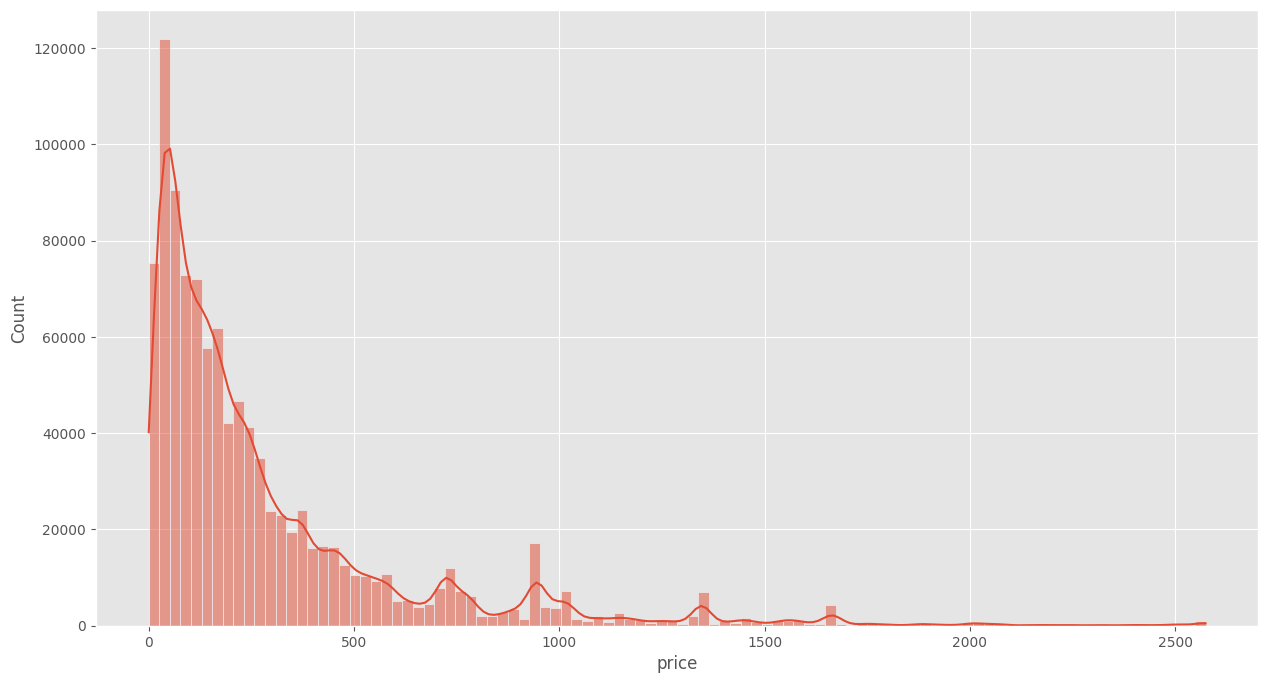

In [16]:
#Price Distribution
plt.figure(figsize=(15,8))
sns.histplot(df2['price'],bins=100,kde=True,palette='viridis')
plt.show()

C:\Users\Priyanshu sharma\AppData\Local\Temp\ipykernel_9752\544229256.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df2, x='event_type', y='price',palette='pastel')


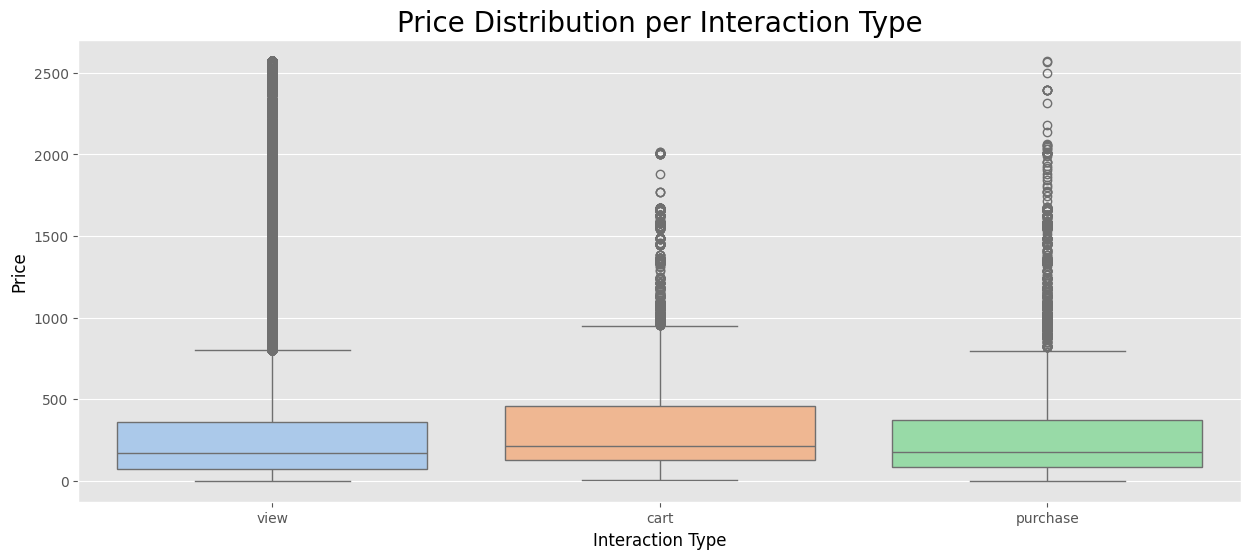

view : 96.39%
purchase : 1.84%
cart : 1.76%


In [17]:
#Price Distribution with Interactions
plt.figure(figsize=(15,6))
sns.boxplot(data=df2, x='event_type', y='price',palette='pastel')
plt.title('Price Distribution per Interaction Type',size=20,color='black')
plt.xlabel('Interaction Type',color='black')
plt.ylabel('Price',color='black')
plt.show()

event_distribution = (df2.groupby('event_type')['price'].sum()/df2['price'].sum()*100).round(2)
event_distribution = event_distribution.sort_values(ascending=False)
for i,j in event_distribution.items():
    print(f"{i} : {j}%") 

C:\Users\Priyanshu sharma\AppData\Local\Temp\ipykernel_9752\396162020.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df2, x='category', y='price',palette='pastel')


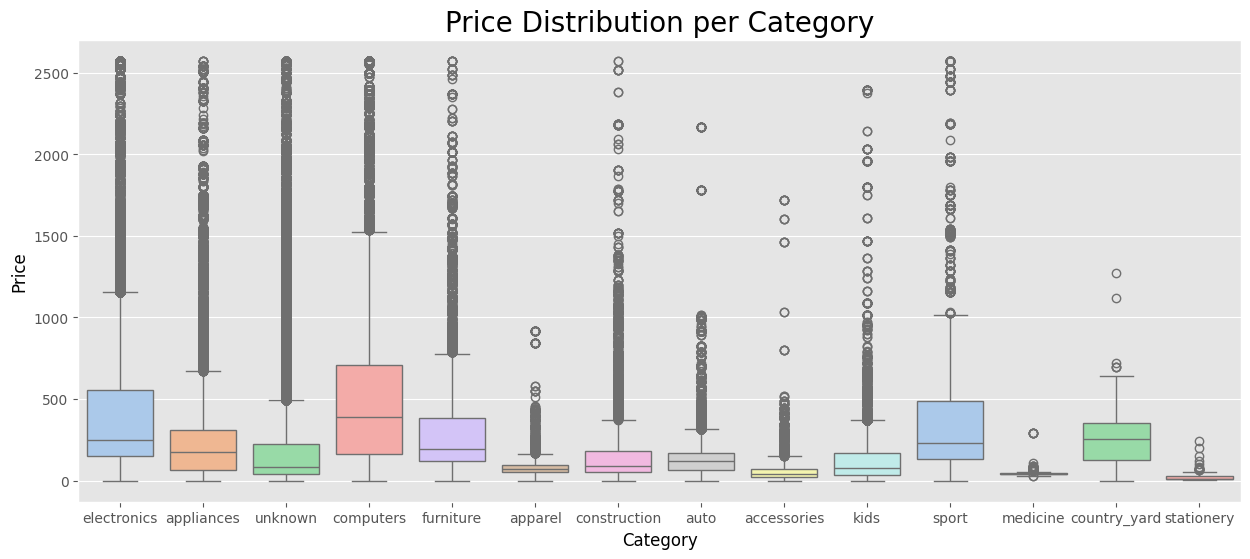

electronics : 53.43%
unknown : 19.12%
computers : 10.26%
appliances : 8.77%
furniture : 4.34%
apparel : 1.07%
construction : 0.88%
auto : 0.86%
kids : 0.65%
sport : 0.5%
accessories : 0.11%
country_yard : 0.03%
medicine : 0.01%
stationery : 0.0%


In [18]:
#Price Distribution with Categories
plt.figure(figsize=(15,6))
sns.boxplot(data=df2, x='category', y='price',palette='pastel')
plt.title('Price Distribution per Category',size=20,color='black')
plt.xlabel('Category',color='black')
plt.ylabel('Price',color='black')
plt.show()

cat_distribution = (df2.groupby('category')['price'].sum()/df['price'].sum()*100).round(2)
cat_distribution = cat_distribution.sort_values(ascending=False)
for i,j in cat_distribution.items():
    print(f"{i} : {j}%")

**PRICE INSIGHTS**
>- There are outliers in the price column
>- price data is right skewed
>- Major chunk of price distribution lies between 0-500
>- All type of categories & interactions do have outliers
>- view interactions have 96.3% of price distribution
>- electronics category have more than 50% of price distribution
>- top 4 categories have more than 90% pf price distribution  

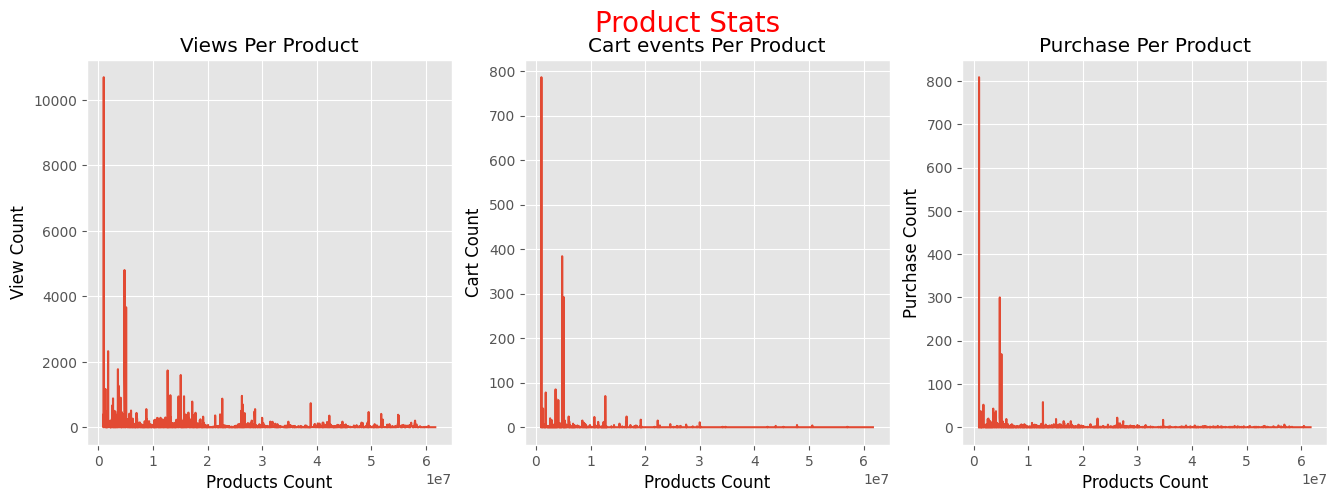

Total Products : 67354
Total Purchased Products : 4910
Unpurchased Products : 62444
7.29% of Products account for 100% Purchases


In [24]:
#Product Analysis
product_stats = df.groupby('product_id').agg(
    interactions = ('event_type','count'),
    purchase = ('event_type',lambda x : (x=='purchase').sum()),
    cart = ('event_type',lambda x :(x=='cart').sum()),
    view = ('event_type',lambda x:(x=='view').sum()),
    users = ('user_id','nunique'),
    avg_price=('price','mean'))

#Visualization
plt.figure(figsize=(16,5))
plt.suptitle('Product Stats',size=20,color='r')
plt.subplot(1,3,1)
sns.lineplot(product_stats['view'])
plt.title('Views Per Product',color='black')
plt.xlabel('Products Count',color='black')
plt.ylabel('View Count',color='black')

plt.subplot(1,3,2)
sns.lineplot(product_stats['cart'])
plt.title('Cart events Per Product',color='black')
plt.xlabel('Products Count',color='black')
plt.ylabel('Cart Count',color='black')

plt.subplot(1,3,3)
sns.lineplot(product_stats['purchase'])
plt.title('Purchase Per Product',color='black')
plt.xlabel('Products Count',color='black')
plt.ylabel('Purchase Count',color='black')

plt.show()

#End Report
print(f'Total Products : {len(product_stats)}')
print(f'Total Purchased Products : {(product_stats['purchase']>0).sum()}')
print(f'Unpurchased Products : {(product_stats["purchase"]==0).sum()}')
print(f'{((product_stats['purchase']>0).sum()/len(product_stats)*100).round(2)}% of Products account for 100% of Purchases')

**PRODUCT INSIGHTS**
>- Out of 67354 total products, only 4910 were ever purchased - rest 62444 were just viewed or carted
>- Most products have very few views, cart events and purchases - long tail distribution
>- A small group of products near the start are getting most of the interactions
>- 7.29% of products account for 100% of purchases
>- Most products on the right side of the graph are nearly dead — no real engagement

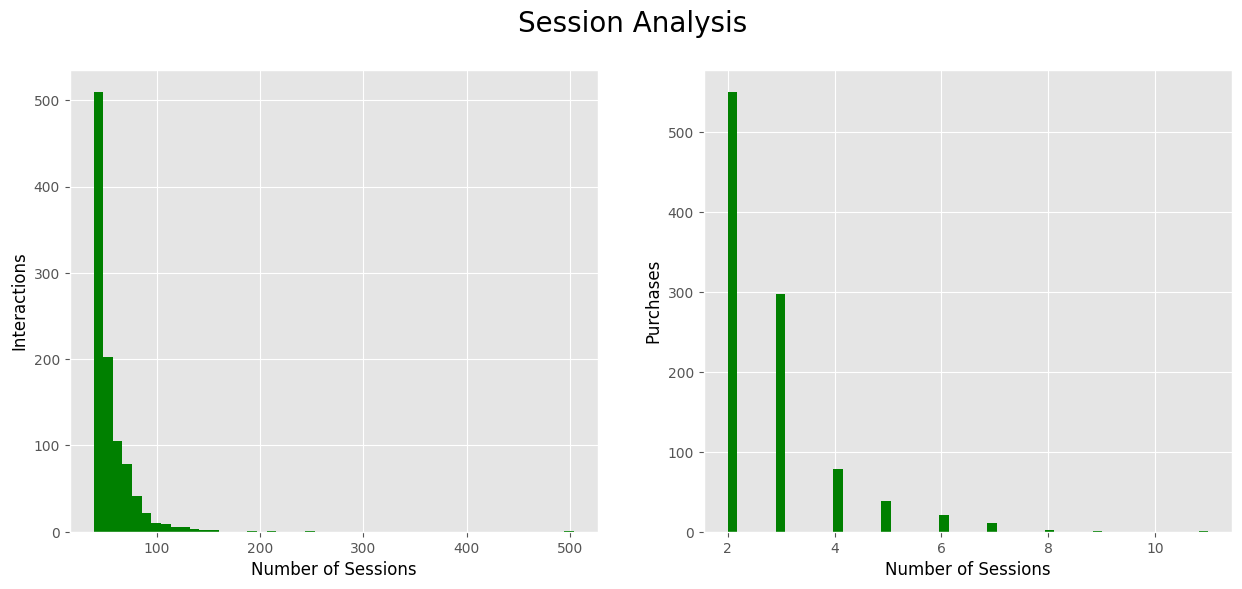

Total user sessions : 247306
Total Interactions : 1048575
Total Purchases : 18368
Highest number of purchases in a session : 11
Ratio of users who Purchased : 6.4%
Average number of products user interacted with in a session : 2.74
Average duration of Interaction : 295.01


In [100]:
#User sessions analysis
session_stats = df.groupby('user_session').agg(
    interactions = ('event_type','count'),
    products = ('product_id','nunique'),
    categories = ('category_code','nunique'),
    purchases = ('event_type',(lambda x :(x=='purchase').sum())),
    carts = ('event_type',(lambda x :(x=='cart').sum())),
    duration_seconds = ('event_time',lambda x:(x.max()-x.min()).total_seconds())
)
purchase_session_stats = session_stats[session_stats['purchases']>0]

#Visualization
plt.figure(figsize=(15,6))
plt.suptitle('Session Analysis',size=20,color='black')
plt.subplot(1,2,1)
plt.hist(session_stats['interactions'].sort_values(ascending=False).head(1000),bins=50,color='g')
plt.xlabel('Number of Sessions',color='black')
plt.ylabel('Interactions',color='black')
plt.subplot(1,2,2)
plt.hist(session_stats['purchases'].sort_values(ascending=False).head(1000),bins=50,color='g')
plt.xlabel('Number of Sessions',color='black')
plt.ylabel('Purchases',color='black')
plt.show()

#End Report
print(f'Total user sessions : {len(session_stats)}')
print(f'Total Interactions : {session_stats['interactions'].sum()}')
print(f'Total Purchases : {session_stats['purchases'].sum()}')
print(f'Highest number of purchases in a session : {session_stats['purchases'].max()}')
print(f"Ratio of users who Purchased : {round(len(purchase_session_stats)/len(session_stats)*100, 2)}%")
print(f'Average number of products user interacted with in a session : {round(session_stats['products'].mean(),2)}')
print(f'Average duration of Interaction : {round(session_stats['duration_seconds'].mean(),2)}')

**SESSION INSIGHTS**
>- There is a total of 2,47,306 unique user sessions
>- These user sessions recorded over 1 million interactions
>- Only 6.4% of total sessions had at least one purchase
>- The average count of interaction with unique products per session is close to 3 that means many people do interact with multiple products in a session to make buying decisions
>- The average duration of a session is almost 5 mins
>- Most sessions have very few interactions, only a small number of sessions have high interaction counts
>- In sessions where a purchase was made, majority had 2-3 purchases in that single session

In [101]:
n_users    = df['user_id'].nunique()
n_products = df['product_id'].nunique()
n_interactions = len(df[df['event_type'] == 'purchase'])
n_unique_pairs = df[df['event_type'] == 'purchase'].drop_duplicates(['user_id', 'product_id']).shape[0]
matrix_size = n_users * n_products
sparsity    = 1 - (n_unique_pairs / matrix_size)

print(f'Unique users         : {n_users:,}')
print(f'Unique products      : {n_products:,}')
print(f'Matrix size          : {matrix_size:,}')
print(f'Purchase interactions: {n_interactions:,}')
print(f'Unique user-item pairs: {n_unique_pairs:,}')
print(f'Matrix Sparsity : {sparsity*100:.4f}%')
print(f'Only {(1-sparsity)*100:.4f}% of the matrix is filled.')

Unique users         : 176,639
Unique products      : 67,354
Matrix size          : 11,897,343,206
Purchase interactions: 18,368
Unique user-item pairs: 16,180
Matrix Sparsity : 99.9999%
Only 0.0001% of the matrix is filled.
